# DSA_06 — Weather Scenario View Prototypes

**Purpose.** Validate how precomputed Model-v1 temperature-sensitivity results
are presented. No model is loaded in this notebook.

In [1]:
# Import libraries
from pathlib import Path
import pandas as pd, yaml, matplotlib.pyplot as plt


In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

cfg = yaml.safe_load(
    (PROJECT_ROOT / "configs" / "decision_support_app.yaml")
    .read_text(encoding="utf-8")
)


In [3]:
# Define path
path = PROJECT_ROOT / cfg["paths"]["demo_weather_scenarios"]
path

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/data/app/demo_weather_scenarios.parquet')

In [4]:
if not path.exists():
    raise FileNotFoundError("Run DSA_02 weather-scenario generation first.")

scenarios = pd.read_parquet(path)
scenarios["forecast_origin"] = pd.to_datetime(scenarios["forecast_origin"])
scenarios["target_timestamp"] = pd.to_datetime(scenarios["target_timestamp"])

display(
    scenarios[
        ["scenario", "temperature_delta_c"]
    ].drop_duplicates().sort_values("temperature_delta_c")
)

,scenario,temperature_delta_c
0,-5C,-5.0
24,-2.5C,-2.5
48,Baseline,0.0
72,+2.5C,2.5
96,+5C,5.0


In [6]:
origin = scenarios["forecast_origin"].min()
scenario_name = (
    "Baseline"
    if "Baseline" in scenarios["scenario"].astype(str).unique()
    else scenarios["scenario"].astype(str).iloc[0]
)

sample = scenarios[
    scenarios["forecast_origin"].eq(origin)
    & scenarios["scenario"].astype(str).eq(scenario_name)
]

matrix = sample.pivot(
    index="fsa",
    columns="horizon",
    values="forecast_delta_kwh",
)

In [7]:
matrix

horizon,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
fsa,,,,,,,,,,,,,,,,,,,,,
L4T,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M5R,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M5S,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M6G,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M9R,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M9W,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


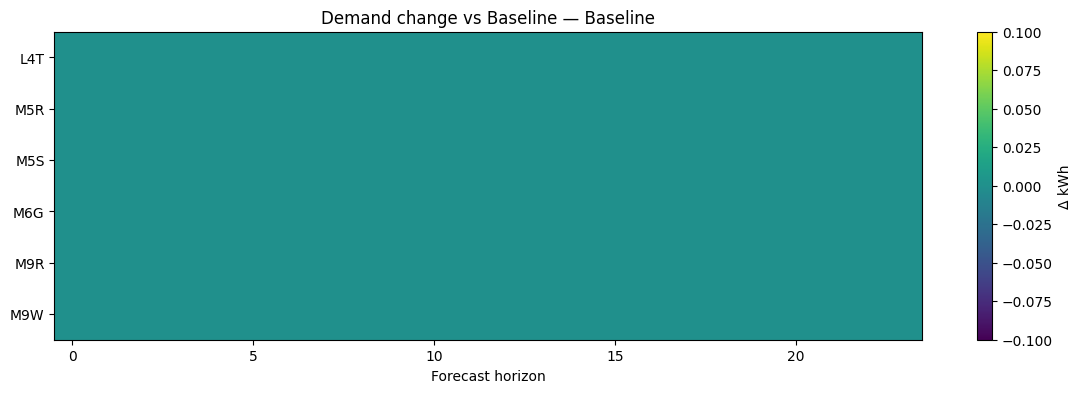

DSA_06 RESULT: COMPLETE


In [8]:
# Plot changes
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(matrix.values, aspect="auto")
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)
ax.set_xlabel("Forecast horizon")
ax.set_title(f"Demand change vs Baseline — {scenario_name}")
fig.colorbar(im, ax=ax, label="Δ kWh")
plt.show()

print("DSA_06 RESULT: COMPLETE")